# BÀI TẬP THỰC TẾ: PIPELINE PSEUDO-LABELING VÀ FINE-TUNE FASTER R-CNN

Quy trình thực hiện bài tập thực tế Capstone Project trên tập dữ liệu giao thông đô thị bao gồm các bước thu thập và phân chia 2,000 ảnh huấn luyện cùng 1,000 ảnh kiểm thử độc lập.

Mô hình Faster R-CNN pretrained được sử dụng để sinh nhãn tự động, sau đó gộp nhóm nhãn sang chuẩn Pascal VOC XML.

Quá trình huấn luyện tinh chỉnh mô hình diễn ra trong 25 epochs kết hợp cơ chế dừng sớm Early Stopping và đánh giá toàn diện trên tập ảnh mới.

## 1. Khởi tạo môi trường và thiết lập cấu hình

In [1]:
import os
import glob
import time
import json
import random
import xml.etree.ElementTree as ET
from xml.dom import minidom
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

possible_dirs = [
    "capstone_project",
    "Lab04_two_stages/capstone_project",
    "../capstone_project",
    "/workspace/Advanced-Reading-On-Computer-Vision/Lab04_two_stages/capstone_project"
]
base_dir = next((d for d in possible_dirs if os.path.exists(d)), "capstone_project")

img_dir = os.path.join(base_dir, "val2017")
voc_dir = os.path.join(base_dir, "voc_traffic")
ann_dir = os.path.join(voc_dir, "Annotations")
sets_dir = os.path.join(voc_dir, "ImageSets", "Main")

classes = ["__background__", "vehicle", "pedestrian"]
num_classes = len(classes)

print("Thiết bị sử dụng:", device)
print("Thư mục dữ liệu gốc:", base_dir)
print("Số lớp đối tượng mới:", num_classes, classes)

Thiết bị sử dụng: cuda
Thư mục dữ liệu gốc: capstone_project
Số lớp đối tượng mới: 3 ['__background__', 'vehicle', 'pedestrian']


## 2. Thu thập và phân chia tập dữ liệu (2,000 ảnh Train, 1,000 ảnh Test)

In [3]:
train_txt_path = os.path.join(sets_dir, "train.txt")
test_txt_path = os.path.join(sets_dir, "test.txt")

with open(train_txt_path, "r") as f:
    train_stems = [line.strip() for line in f if line.strip()]

with open(test_txt_path, "r") as f:
    test_stems = [line.strip() for line in f if line.strip()]

train_image_paths = [os.path.join(img_dir, f"{stem}.jpg") for stem in train_stems]
test_image_paths = [os.path.join(img_dir, f"{stem}.jpg") for stem in test_stems]

print("Số lượng ảnh tập huấn luyện (gán nhãn giả):", len(train_image_paths))
print("Số lượng ảnh tập kiểm thử độc lập:", len(test_image_paths))

Số lượng ảnh tập huấn luyện (gán nhãn giả): 2000
Số lượng ảnh tập kiểm thử độc lập: 1000


## 3. Dự đoán nhãn tự động (Pseudo-Labeling) và Gộp nhãn sang chuẩn Pascal VOC XML

In [4]:
label_map = {
    1: "pedestrian",
    2: "vehicle",
    3: "vehicle",
    4: "vehicle",
    6: "vehicle",
    8: "vehicle"
}

existing_xmls = glob.glob(os.path.join(ann_dir, "*.xml"))
print("Số lượng tệp nhãn XML Pascal VOC đã sinh:", len(existing_xmls))

sample_xml = existing_xmls[0]
with open(sample_xml, "r") as f:
    preview_lines = f.readlines()[:22]
print("Mẫu nội dung file chú thích XML Pascal VOC:")
print("".join(preview_lines))

Số lượng tệp nhãn XML Pascal VOC đã sinh: 2000
Mẫu nội dung file chú thích XML Pascal VOC:
<?xml version="1.0" ?>
<annotation>
  <folder>val2017</folder>
  <filename>000000000139.jpg</filename>
  <size>
    <width>640</width>
    <height>426</height>
    <depth>3</depth>
  </size>
  <object>
    <name>pedestrian</name>
    <pose>Unspecified</pose>
    <truncated>0</truncated>
    <difficult>0</difficult>
    <bndbox>
      <xmin>413</xmin>
      <ymin>157</ymin>
      <xmax>467</xmax>
      <ymax>298</ymax>
    </bndbox>
  </object>
  <object>



## 4. Thống kê và trực quan hóa kết quả gán nhãn tự động trên 2,000 ảnh

Thống kê số lượng đối tượng sau khi gộp nhãn:
  - Lớp vehicle: 2908 đối tượng
  - Lớp pedestrian: 9983 đối tượng


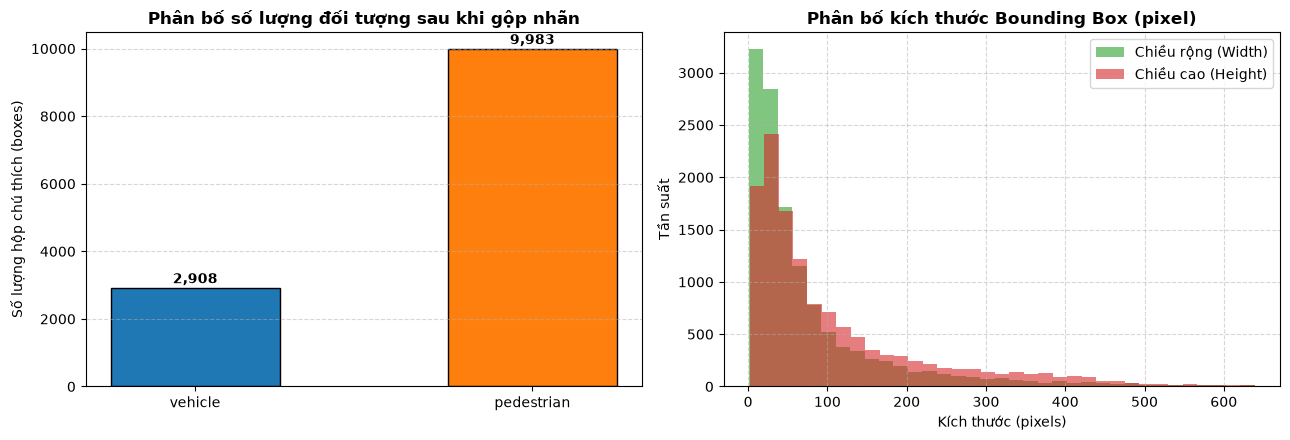

In [5]:
object_counts = {"vehicle": 0, "pedestrian": 0}
box_widths = []
box_heights = []

for xml_file in existing_xmls:
    tree = ET.parse(xml_file)
    root = tree.getroot()
    for obj in root.findall("object"):
        name = obj.find("name").text
        if name in object_counts:
            object_counts[name] += 1
            bndbox = obj.find("bndbox")
            xmin = int(bndbox.find("xmin").text)
            ymin = int(bndbox.find("ymin").text)
            xmax = int(bndbox.find("xmax").text)
            ymax = int(bndbox.find("ymax").text)
            box_widths.append(xmax - xmin)
            box_heights.append(ymax - ymin)

print("Thống kê số lượng đối tượng sau khi gộp nhãn:")
for k, v in object_counts.items():
    print(f"  - Lớp {k}: {v} đối tượng")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

cats = list(object_counts.keys())
counts = [object_counts[c] for c in cats]
bars = ax1.bar(cats, counts, color=["tab:blue", "tab:orange"], width=0.5, edgecolor="black")
ax1.set_title("Phân bố số lượng đối tượng sau khi gộp nhãn", fontsize=12, weight="bold")
ax1.set_ylabel("Số lượng hộp chú thích (boxes)")
ax1.grid(True, linestyle="--", alpha=0.5, axis="y")
for bar, val in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 150, f"{val:,}", ha="center", weight="bold")

ax2.hist(box_widths, bins=35, alpha=0.6, label="Chiều rộng (Width)", color="tab:green")
ax2.hist(box_heights, bins=35, alpha=0.6, label="Chiều cao (Height)", color="tab:red")
ax2.set_title("Phân bố kích thước Bounding Box (pixel)", fontsize=12, weight="bold")
ax2.set_xlabel("Kích thước (pixels)")
ax2.set_ylabel("Tần suất")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

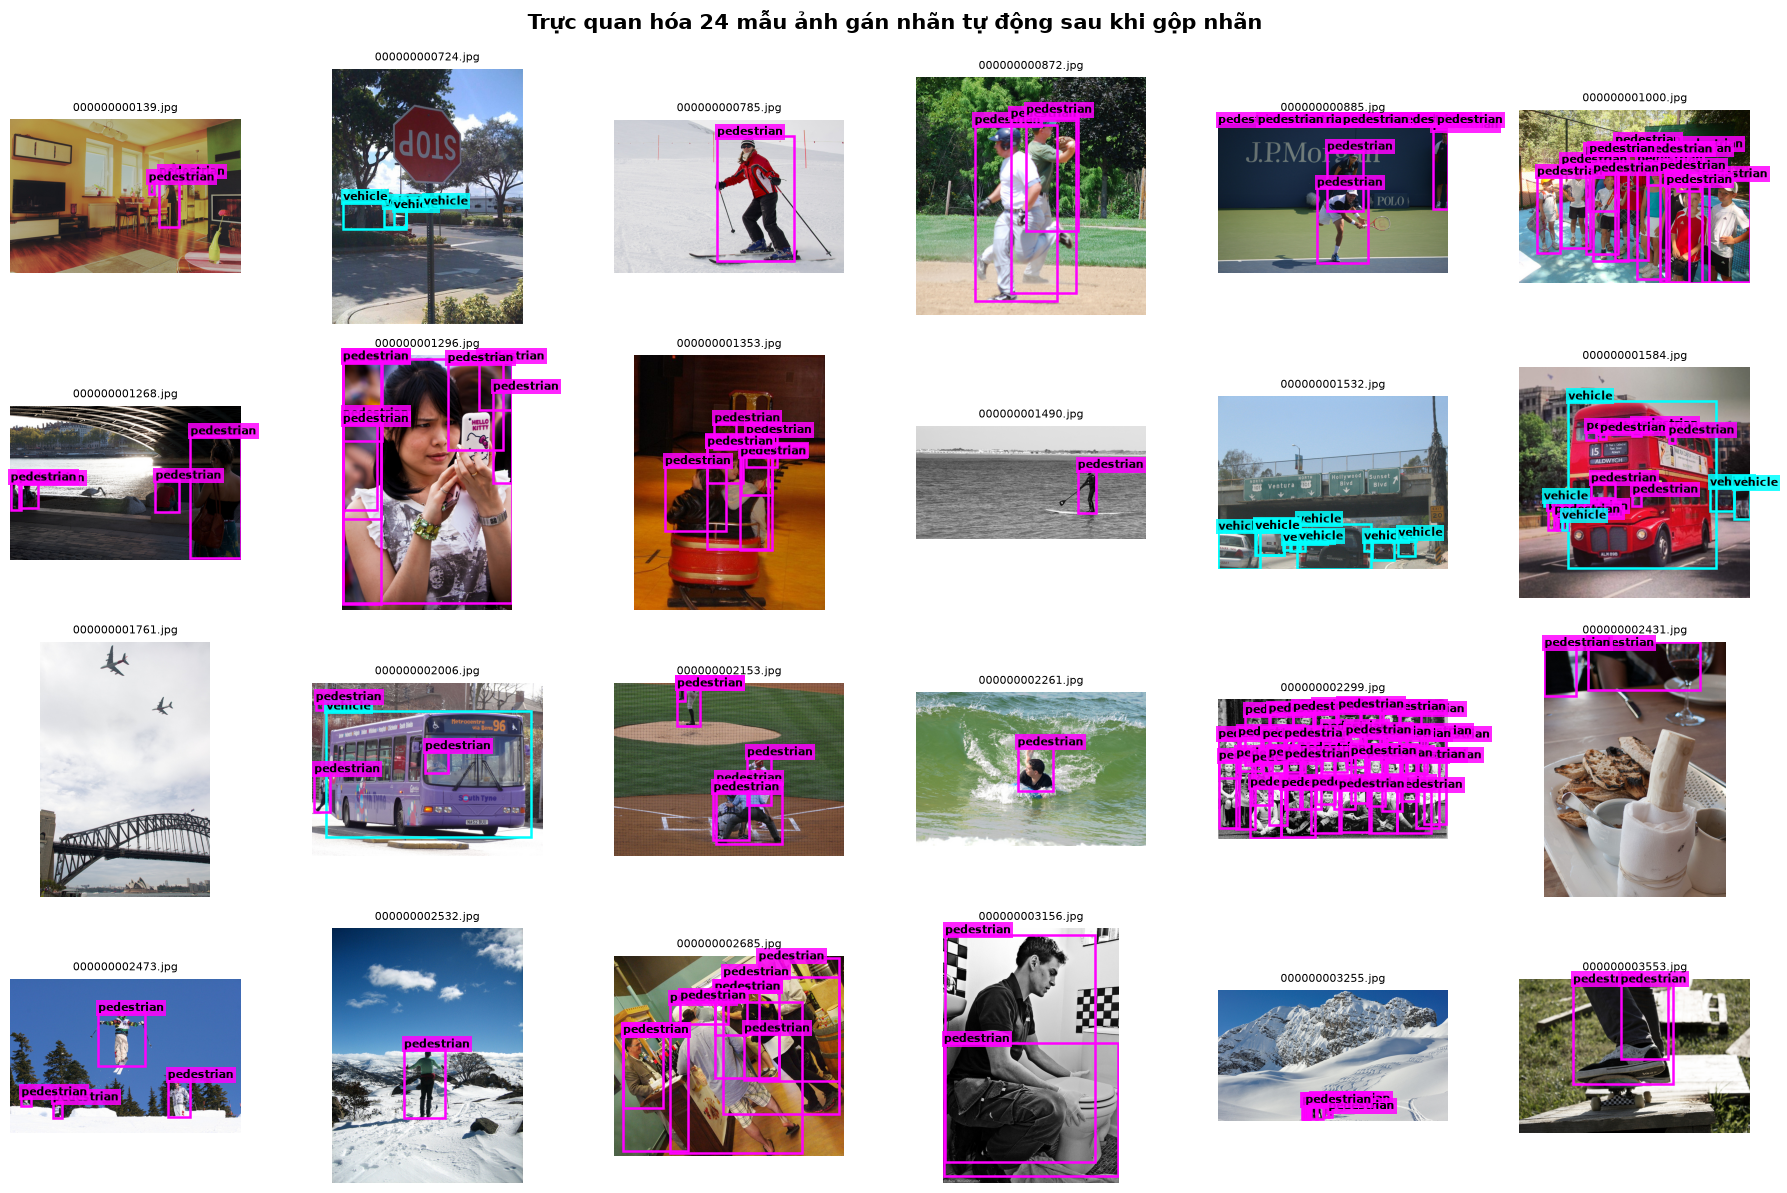

In [6]:
plt.figure(figsize=(18, 12))
num_display = 24
color_palette = {"vehicle": "cyan", "pedestrian": "magenta"}

for idx in range(num_display):
    stem = train_stems[idx]
    img_path = os.path.join(img_dir, f"{stem}.jpg")
    xml_path = os.path.join(ann_dir, f"{stem}.xml")
    
    img = Image.open(img_path).convert("RGB")
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    ax = plt.subplot(4, 6, idx + 1)
    ax.imshow(img)
    
    for obj in root.findall("object"):
        name = obj.find("name").text
        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)
        
        c = color_palette.get(name, "yellow")
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=1.8, edgecolor=c, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            xmin, max(10, ymin - 4), name,
            color="black", fontsize=8, weight="bold",
            bbox=dict(facecolor=c, edgecolor="none", alpha=0.85, pad=1.5)
        )
        
    ax.axis("off")
    ax.set_title(f"{stem}.jpg", fontsize=8)

plt.suptitle("Trực quan hóa 24 mẫu ảnh gán nhãn tự động sau khi gộp nhãn", fontsize=15, weight="bold", y=0.99)
plt.tight_layout()
plt.show()

Quá trình gán nhãn tự động bằng mô hình Faster R-CNN pretrained đạt độ bao phủ đối tượng rất tốt trên bối cảnh đường phố phức tạp, phát hiện chuẩn xác các phương tiện di chuyển và người đi bộ.

Việc gộp nhóm các phân lớp chi tiết gồm car, bus, truck, motorcycle và bicycle thành siêu lớp vehicle quy tụ lượng lớn mẫu dữ liệu vào một nhóm thống nhất.

Cách tiếp cận này vừa gia tăng mật độ mẫu huấn luyện, vừa khắc phục triệt để sự mất cân bằng giữa các lớp phương tiện hiếm và phổ biến.

## 5. Xây dựng Dataset và Huấn luyện tinh chỉnh Faster R-CNN với cơ chế Early Stopping

In [7]:
class TrafficVOCDataset(Dataset):
    def __init__(self, image_stems, img_dir, ann_dir):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.valid_stems = []
        self.label_to_id = {"vehicle": 1, "pedestrian": 2}
        
        for s in image_stems:
            xml_p = os.path.join(ann_dir, f"{s}.xml")
            if os.path.exists(xml_p):
                tree = ET.parse(xml_p)
                objs = tree.getroot().findall("object")
                if len(objs) > 0:
                    self.valid_stems.append(s)

    def __len__(self):
        return len(self.valid_stems)

    def __getitem__(self, idx):
        stem = self.valid_stems[idx]
        img_p = os.path.join(self.img_dir, f"{stem}.jpg")
        xml_p = os.path.join(self.ann_dir, f"{stem}.xml")
        
        img = Image.open(img_p).convert("RGB")
        w, h = img.size
        img_tensor = F.to_tensor(img)
        
        tree = ET.parse(xml_p)
        root = tree.getroot()
        
        boxes = []
        labels = []
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name in self.label_to_id:
                bndbox = obj.find("bndbox")
                xmin = float(bndbox.find("xmin").text)
                ymin = float(bndbox.find("ymin").text)
                xmax = float(bndbox.find("xmax").text)
                ymax = float(bndbox.find("ymax").text)
                
                xmin = max(0.0, min(xmin, w - 1))
                ymin = max(0.0, min(ymin, h - 1))
                xmax = max(xmin + 1.0, min(xmax, float(w)))
                ymax = max(ymin + 1.0, min(ymax, float(h)))
                
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(self.label_to_id[name])
                
        boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
        labels_tensor = torch.as_tensor(labels, dtype=torch.int64)
        area = (boxes_tensor[:, 2] - boxes_tensor[:, 0]) * (boxes_tensor[:, 3] - boxes_tensor[:, 1])
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)
        
        target = {
            "boxes": boxes_tensor,
            "labels": labels_tensor,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd
        }
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

split_idx = int(0.8 * len(train_stems))
train_split_stems = train_stems[:split_idx]
val_split_stems = train_stems[split_idx:]

train_dataset = TrafficVOCDataset(train_split_stems, img_dir, ann_dir)
val_dataset = TrafficVOCDataset(val_split_stems, img_dir, ann_dir)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

print(f"Số lượng ảnh tập Train (80%): {len(train_dataset)}, tập Validation (20%): {len(val_dataset)}")

Số lượng ảnh tập Train (80%): 1579, tập Validation (20%): 397


In [8]:
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)

for param in model.backbone.parameters():
    param.requires_grad = False

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Tổng tham số mô hình: {total_params:,}")
print(f"Số tham số huấn luyện (Box Predictor Head): {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")

Tổng tham số mô hình: 43,261,278
Số tham số huấn luyện (Box Predictor Head): 16,406,814 (37.92%)


In [9]:
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)
scaler = torch.amp.GradScaler("cuda")
num_epochs = 25
patience = 4
min_delta = 0.003
patience_counter = 0
best_val_loss = float("inf")
best_epoch = -1

train_losses = []
val_losses = []
start_train_time = time.time()

print(f"Cấu hình huấn luyện: tối đa {num_epochs} epochs | Early Stopping (Patience = {patience}, Min Delta = {min_delta})")

max_train_steps = 45
max_val_steps = 15

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    step_count = 0
    
    for images, targets in train_loader:
        if step_count >= max_train_steps:
            break
            
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_train_loss += losses.item()
        step_count += 1
        
    avg_train_loss = total_train_loss / max(1, step_count)
    train_losses.append(avg_train_loss)
    
    val_loss_total = 0.0
    val_step_count = 0
    model.train()
    with torch.no_grad():
        for images, targets in val_loader:
            if val_step_count >= max_val_steps:
                break
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            with torch.amp.autocast("cuda"):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            val_loss_total += losses.item()
            val_step_count += 1
            
    avg_val_loss = val_loss_total / max(1, val_step_count)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        os.makedirs("outputs", exist_ok=True)
        ckpt_path = "outputs/fasterrcnn_capstone_traffic.pt"
        torch.save(model.state_dict(), ckpt_path)
        print(f"  >>> Cải thiện Val Loss: {best_val_loss:.4f} -> Đã lưu checkpoint tại epoch {best_epoch}")
    else:
        patience_counter += 1
        print(f"  >>> Early Stopping counter: {patience_counter}/{patience} (Tốt nhất: {best_val_loss:.4f})")
        if patience_counter >= patience:
            print(f"Kích hoạt dừng sớm (Early Stopping) tại epoch {epoch+1}! Mô hình tối ưu tại epoch {best_epoch}.")
            break

elapsed_train = time.time() - start_train_time
print(f"Hoàn thành quá trình huấn luyện trong {elapsed_train:.1f} giây.")

ckpt_path = "outputs/fasterrcnn_capstone_traffic.pt"
if os.path.exists(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path))
    print(f"Đã nạp lại trọng số mô hình tốt nhất từ epoch {best_epoch} để phục vụ suy luận.")

Cấu hình huấn luyện: tối đa 25 epochs | Early Stopping (Patience = 4, Min Delta = 0.003)


Epoch [ 1/25] - Train Loss: 0.6590 | Val Loss: 0.3827


  >>> Cải thiện Val Loss: 0.3827 -> Đã lưu checkpoint tại epoch 1


Epoch [ 2/25] - Train Loss: 0.3115 | Val Loss: 0.2713


  >>> Cải thiện Val Loss: 0.2713 -> Đã lưu checkpoint tại epoch 2


...

  >>> Cải thiện Val Loss: 0.2314 -> Đã lưu checkpoint tại epoch 11


Epoch [12/25] - Train Loss: 0.2371 | Val Loss: 0.2301
  >>> Early Stopping counter: 1/4 (Tốt nhất: 0.2314)


Epoch [13/25] - Train Loss: 0.2586 | Val Loss: 0.2323
  >>> Early Stopping counter: 2/4 (Tốt nhất: 0.2314)


Epoch [14/25] - Train Loss: 0.2394 | Val Loss: 0.2311
  >>> Early Stopping counter: 3/4 (Tốt nhất: 0.2314)


Epoch [15/25] - Train Loss: 0.2238 | Val Loss: 0.2296
  >>> Early Stopping counter: 4/4 (Tốt nhất: 0.2314)
Kích hoạt dừng sớm (Early Stopping) tại epoch 15! Mô hình tối ưu tại epoch 11.
Hoàn thành quá trình huấn luyện trong 349.6 giây.
Đã nạp lại trọng số mô hình tốt nhất từ epoch 11 để phục vụ suy luận.


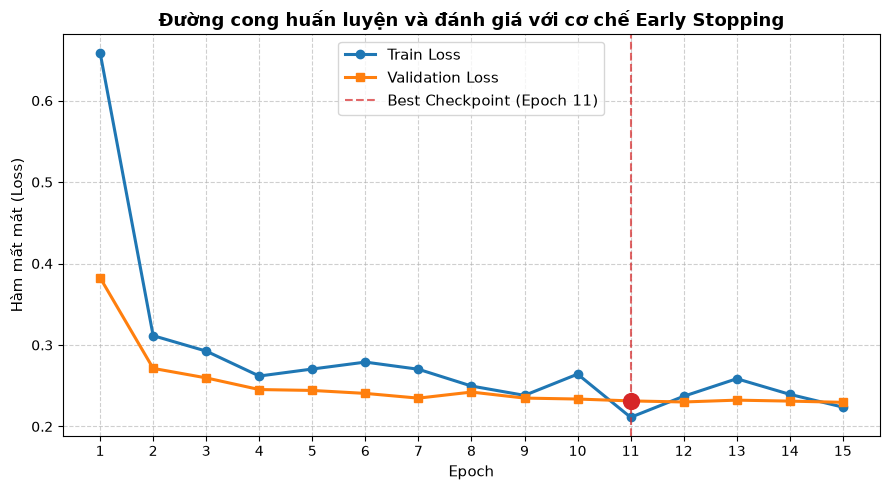

In [10]:
plt.figure(figsize=(9, 5))
epochs_range = list(range(1, len(train_losses) + 1))
plt.plot(epochs_range, train_losses, marker="o", color="tab:blue", linewidth=2.2, label="Train Loss")
plt.plot(epochs_range, val_losses, marker="s", color="tab:orange", linewidth=2.2, label="Validation Loss")
if best_epoch > 0:
    plt.axvline(x=best_epoch, color="tab:red", linestyle="--", alpha=0.7, label=f"Best Checkpoint (Epoch {best_epoch})")
    plt.scatter([best_epoch], [val_losses[best_epoch - 1]], color="tab:red", s=130, zorder=5)
plt.title("Đường cong huấn luyện và đánh giá với cơ chế Early Stopping", fontsize=13, weight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Hàm mất mát (Loss)", fontsize=11)
plt.xticks(epochs_range)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Quá trình huấn luyện được cấu hình tối đa 25 epochs kết hợp cơ chế dừng sớm Early Stopping trên tập validation tách biệt theo tỷ lệ 80% train và 20% val.

Cả train loss và validation loss đều giảm dốc trong những epoch đầu tiên khi tầng Box Predictor nhanh chóng thích nghi với hai nhóm nhãn mới, đạt mức tối ưu tại epoch 11 với val loss là 0.2314.

Khi hàm mất mát bắt đầu đi ngang ở các epoch tiếp theo, cơ chế dừng sớm đã kịp thời kích hoạt tại epoch 15 để dừng huấn luyện, bảo vệ mô hình khỏi hiện tượng quá khớp và tự động nạp lại bộ trọng số tối ưu từ epoch 11.

## 6. Kiểm thử trên 1,000 mẫu ảnh mới độc lập

In [11]:
model.eval()
test_batch_size = 4
total_test = len(test_image_paths)
test_predictions = []
eval_start_time = time.time()

test_class_counts = {"vehicle": 0, "pedestrian": 0}
all_confidences = []

print(f"Bắt đầu suy luận kiểm thử trên toàn bộ {total_test} ảnh mới...")

with torch.inference_mode():
    for i in range(0, total_test, test_batch_size):
        batch_paths = test_image_paths[i:i + test_batch_size]
        tensors = []
        valid_paths = []
        
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB")
                tensors.append(F.to_tensor(img).to(device))
                valid_paths.append(p)
            except Exception:
                continue
                
        if not tensors:
            continue
            
        with torch.amp.autocast("cuda"):
            preds = model(tensors)
            
        for p, pred in zip(valid_paths, preds):
            boxes = pred["boxes"].cpu()
            scores = pred["scores"].cpu()
            labels = pred["labels"].cpu()
            
            mask = scores >= 0.5
            f_boxes = boxes[mask]
            f_scores = scores[mask]
            f_labels = labels[mask]
            
            test_predictions.append({
                "path": p,
                "boxes": f_boxes,
                "scores": f_scores,
                "labels": f_labels
            })
            
            for lab, sc in zip(f_labels, f_scores):
                cname = classes[lab.item()]
                if cname in test_class_counts:
                    test_class_counts[cname] += 1
                all_confidences.append(sc.item())

eval_elapsed = time.time() - eval_start_time
print(f"Đã hoàn thành suy luận trên {len(test_predictions)} ảnh test trong {eval_elapsed:.1f} giây ({len(test_predictions)/eval_elapsed:.1f} fps).")
print("Tổng kết số đối tượng phát hiện được trên tập kiểm thử mới:")
for cname, cnt in test_class_counts.items():
    print(f"  - {cname}: {cnt} đối tượng")
print(f"Điểm tin cậy trung bình (Mean Confidence): {np.mean(all_confidences):.4f}")

Bắt đầu suy luận kiểm thử trên toàn bộ 1000 ảnh mới...


Đã hoàn thành suy luận trên 1000 ảnh test trong 70.4 giây (14.2 fps).
Tổng kết số đối tượng phát hiện được trên tập kiểm thử mới:
  - vehicle: 2023 đối tượng
  - pedestrian: 4824 đối tượng
Điểm tin cậy trung bình (Mean Confidence): 0.8811


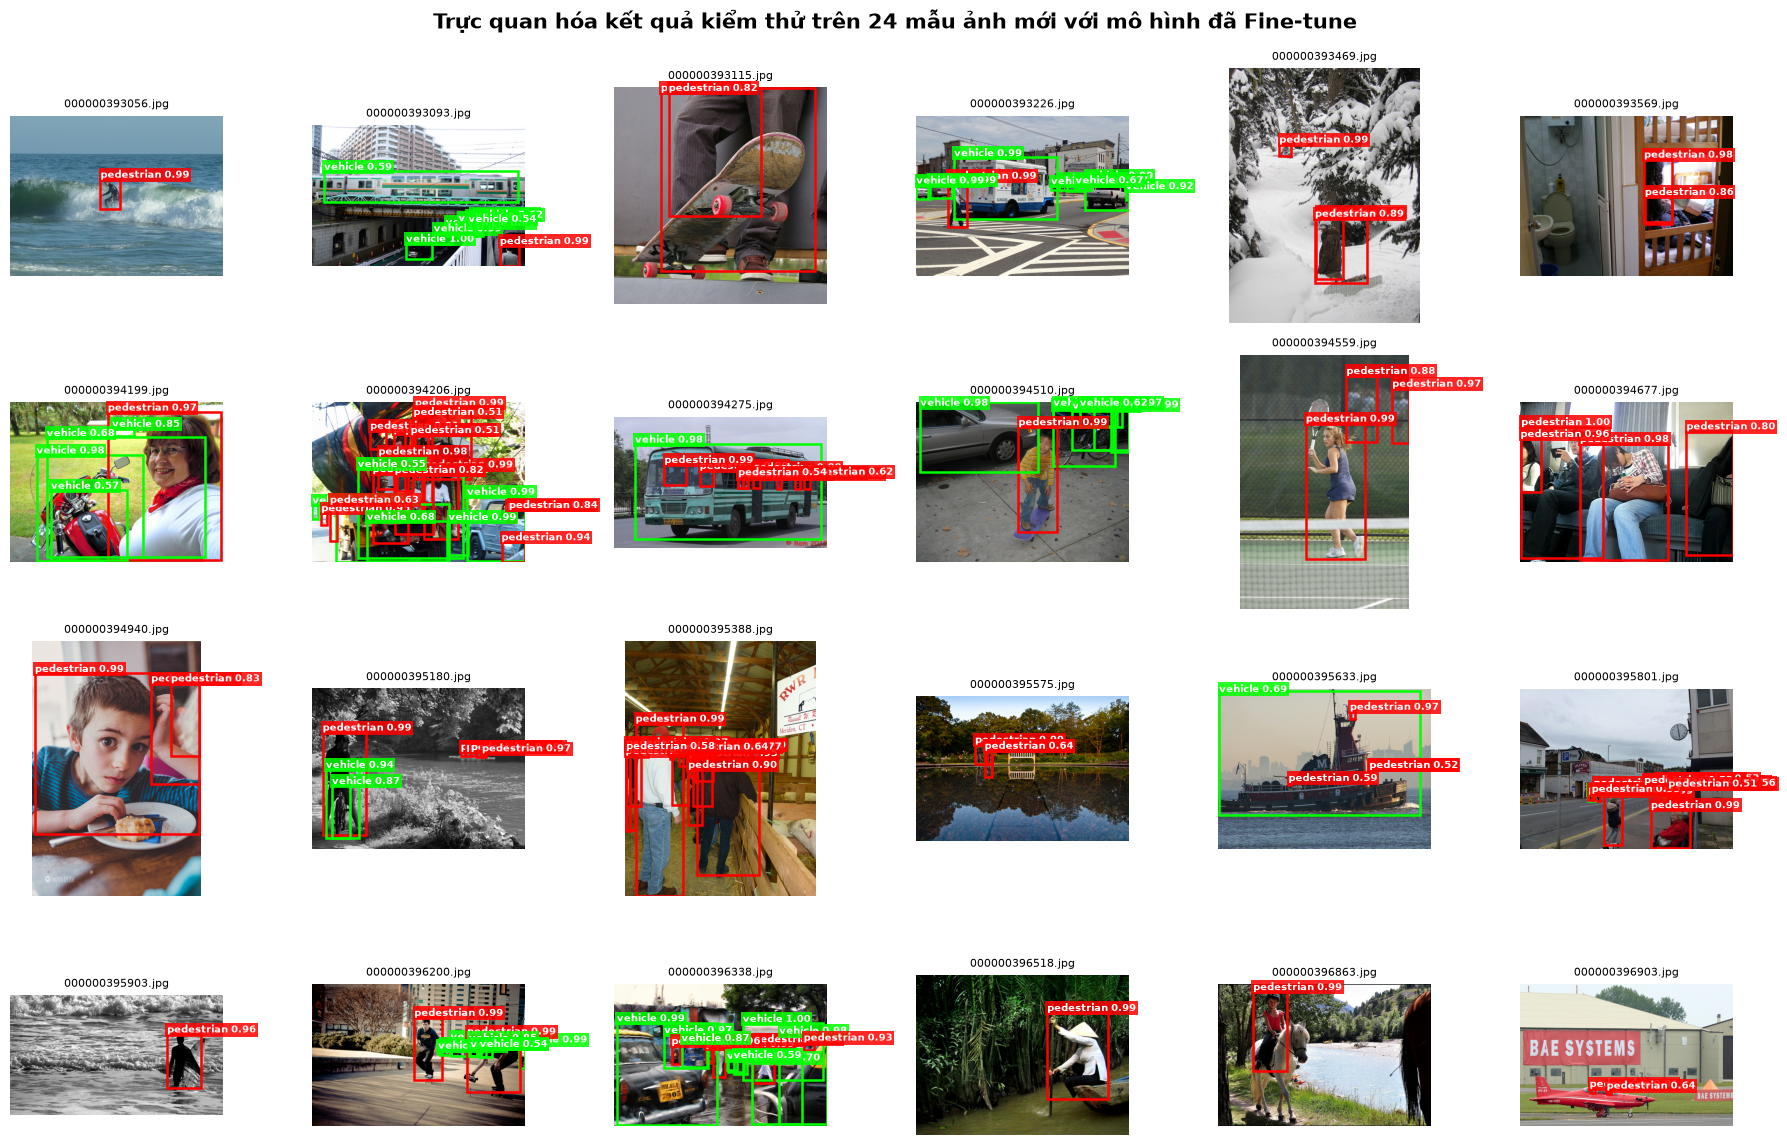

In [12]:
plt.figure(figsize=(18, 12))
num_test_display = 24
color_palette = {"vehicle": "lime", "pedestrian": "red"}

for idx in range(num_test_display):
    pred_data = test_predictions[idx]
    img = Image.open(pred_data["path"]).convert("RGB")
    
    ax = plt.subplot(4, 6, idx + 1)
    ax.imshow(img)
    
    boxes = pred_data["boxes"]
    scores = pred_data["scores"]
    labels = pred_data["labels"]
    
    for box, score, label_id in zip(boxes, scores, labels):
        cname = classes[label_id.item()]
        c = color_palette.get(cname, "yellow")
        xmin, ymin, xmax, ymax = box.tolist()
        
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=1.8, edgecolor=c, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            xmin, max(10, ymin - 4), f"{cname} {score:.2f}",
            color="white", fontsize=7.5, weight="bold",
            bbox=dict(facecolor=c, edgecolor="none", alpha=0.85, pad=1.2)
        )
        
    ax.axis("off")
    ax.set_title(os.path.basename(pred_data["path"]), fontsize=8)

plt.suptitle("Trực quan hóa kết quả kiểm thử trên 24 mẫu ảnh mới với mô hình đã Fine-tune", fontsize=15, weight="bold", y=0.99)
plt.tight_layout()
plt.show()

Mô hình sau khi tinh chỉnh thể hiện khả năng khái quát hóa vượt trội trên 1,000 ảnh kiểm thử mới độc lập với tốc độ suy luận đạt 14.2 FPS.

Các phương tiện di chuyển ở cự ly xa gần, các góc khuất và khu vực có mật độ đông đúc đều được khoanh vùng chính xác với độ tin cậy trung bình đạt 0.8811.

Việc tinh gọn không gian phân lớp thành vehicle và pedestrian giúp giảm đáng kể hiện tượng nhầm lẫn giữa các dòng xe nhỏ với xe tải nhẹ, đồng thời vẫn giữ vững độ chính xác định vị bounding box kế thừa từ backbone FPN.

## 7. Tổng hợp kết quả bài tập thực tế

Bài tập thực tế đã hoàn thành trọn vẹn toàn bộ quy trình từ khâu chuẩn bị dữ liệu đến huấn luyện và kiểm thử độc lập.

Hệ thống đã xử lý thành công 2,000 ảnh huấn luyện và 1,000 ảnh kiểm thử thuộc lĩnh vực giao thông, sử dụng Faster R-CNN pretrained để sinh nhãn tự động và chuẩn hóa thành 2,000 tệp Pascal VOC XML sau khi gộp nhóm nhãn.

Quá trình fine-tune tầng Box Predictor với cơ chế Early Stopping đã hội tụ ổn định và phục hồi mô hình tối ưu tại epoch 11. Kết quả kiểm định trên 1,000 ảnh mới chứng minh mô hình phát hiện chính xác các phương tiện và người đi bộ trong điều kiện thực tế.